# 📊 Analisis Data Mining: Prediksi Keberhasilan Kampanye Deposito Bank (Optimized)

**Proyek:** Bank Term Deposit Classification menggunakan Algoritma **Random Forest**
**Dataset:** `bank.csv` (Mencakup data demografis, riwayat kontak, dan hasil kampanye)

---

## 📝 Deskripsi Proyek

Notebook ini bertujuan untuk melakukan **Klasifikasi Biner** untuk memprediksi probabilitas seorang nasabah dalam berlangganan deposito berjangka (`y` = 'yes' atau 'no'). Dengan mengolah data kampanye pemasaran melalui telepon, institusi perbankan dapat mengidentifikasi karakteristik nasabah potensial secara otomatis. Analisis ini sangat berguna untuk:
*   **Strategi Pemasaran Terarah:** Fokus pada nasabah dengan peluang konversi tinggi.
*   **Efisiensi Operasional:** Mengurangi waktu dan biaya telemarketing yang tidak perlu.
*   **Data-Driven Decision:** Memahami faktor kunci yang mendorong nasabah untuk mengambil produk deposito.

---

## 🛠️ Alur Kerja (Workflow) & Teknikal

Untuk menghasilkan model prediksi yang akurat dan kompetitif, notebook ini menerapkan tahapan berikut:

1.  **Data Ingestion:** Memuat dataset `bank_y_cleaned.csv` dengan penanganan separator khusus (semicolon).
2.  **Data Preprocessing:**
    *   Transformasi fitur kategorikal (Pekerjaan, Status Pernikahan, Pendidikan, dll) menggunakan **One-Hot Encoding**.
    *   Konversi target variabel menjadi format biner (0 & 1).
3.  **Feature Engineering & Scaling:** Normalisasi variabel numerik (seperti Saldo dan Durasi) menggunakan **StandardScaler** untuk performa model yang optimal.
4.  **Handling Imbalanced Data:** Menggunakan strategi `class_weight='balanced'` pada algoritma untuk menangani ketidakseimbangan jumlah data antara nasabah yang berlangganan dan tidak.
5.  **Modeling & Evaluation:**
    *   Implementasi algoritma **Random Forest Classifier**.
    *   Evaluasi menggunakan **Confusion Matrix**, **F1-Score**, dan **Akurasi**.
    *   Visualisasi **Feature Importance** untuk melihat variabel paling berpengaruh.

---

## 🚀 Teknologi yang Digunakan
*   **Bahasa:** Python 3.x
*   **Library Utama:** `Pandas`, `NumPy`, `Scikit-Learn`, `Seaborn`, `Matplotlib`.
*   **Tool Pendukung:** Google Colab, GitHub, Power BI (Visualisasi Dashboard).

---

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
# Tentukan lokasi file
file_path = '/content/drive/MyDrive/Colab Notebooks/bank_y_cleaned.csv'

# Baca file CSV
df = pd.read_csv(file_path)

# Tampilkan 5 data teratas untuk memastikan data masuk
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30.0,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,oct,79.0,1.0,-1.0,0.0,unknown,no
1,33.0,services,married,secondary,no,3596.5,yes,yes,cellular,11.0,may,220.0,1.0,-1.0,0.0,failure,no
2,35.0,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,apr,185.0,1.0,-1.0,0.0,failure,no
3,30.0,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,jun,199.0,4.0,-1.0,0.0,unknown,no
4,59.0,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,may,226.0,1.0,-1.0,0.0,unknown,no


In [17]:
print("\n--- Melakukan Visualisasi EDA ---")


--- Melakukan Visualisasi EDA ---


/tmp/ipykernel_5495/696961441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


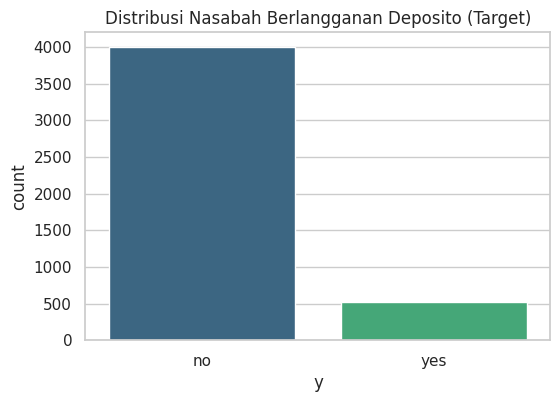

In [14]:
# A. Distribusi Target (y)
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribusi Nasabah Berlangganan Deposito (Target)')
plt.show()

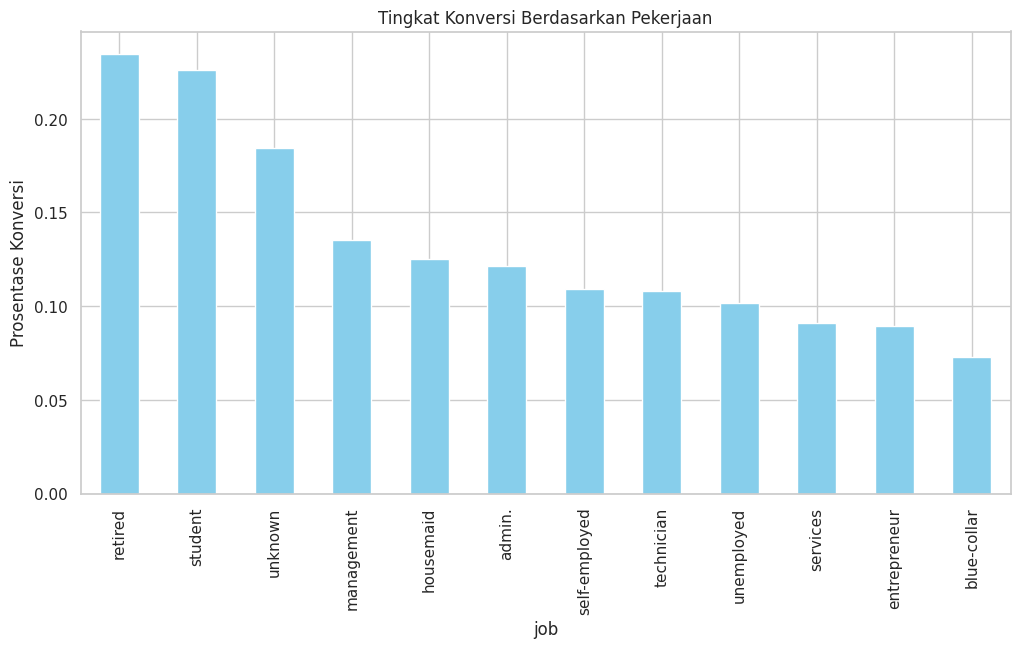

In [15]:
# B. Conversion Rate berdasarkan Job (Seperti di Power BI kamu)
job_conv = df.groupby('job')['y'].value_counts(normalize=True).unstack().fillna(0)
job_conv['yes'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Tingkat Konversi Berdasarkan Pekerjaan')
plt.ylabel('Prosentase Konversi')
plt.show()

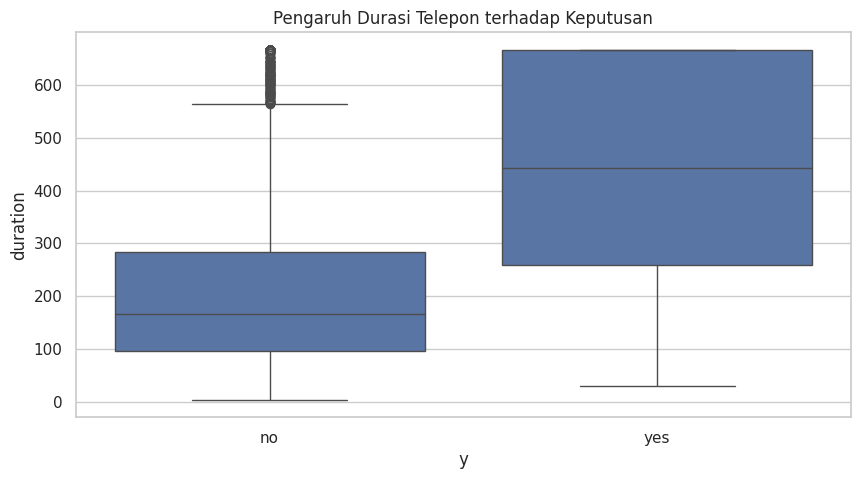

In [16]:
# C. Hubungan Durasi Telepon dengan Keputusan (y)
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Pengaruh Durasi Telepon terhadap Keputusan')
plt.show()

In [18]:
print("\n--- Melakukan Preprocessing Data ---")


--- Melakukan Preprocessing Data ---


In [19]:
# A. Encoding Data Kategorikal
# Pisahkan kolom target
le = LabelEncoder()
df['y'] = le.fit_transform(df['y']) # yes=1, no=0

# One-Hot Encoding untuk fitur kategorikal lainnya
df_encoded = pd.get_dummies(df, drop_first=True)

In [20]:
# B. Pemisahan Fitur (X) dan Target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [21]:
# C. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# D. Handling Imbalanced Data dengan SMOTE
# Ini akan menciptakan data sintetis agar jumlah "yes" seimbang dengan "no"
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Jumlah data sebelum SMOTE: {np.bincount(y_train)}")
print(f"Jumlah data setelah SMOTE: {np.bincount(y_train_res)}")

Jumlah data sebelum SMOTE: [3199  417]
Jumlah data setelah SMOTE: [3199 3199]


In [23]:
# E. Scaling Fitur (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [24]:
print("\n--- Melatih Model Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_res)

# Prediksi
y_pred = rf_model.predict(X_test_scaled)


--- Melatih Model Random Forest ---


In [25]:
print("\n--- Hasil Evaluasi Model ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")


--- Hasil Evaluasi Model ---
Akurasi: 89.39%
F1-Score: 0.50


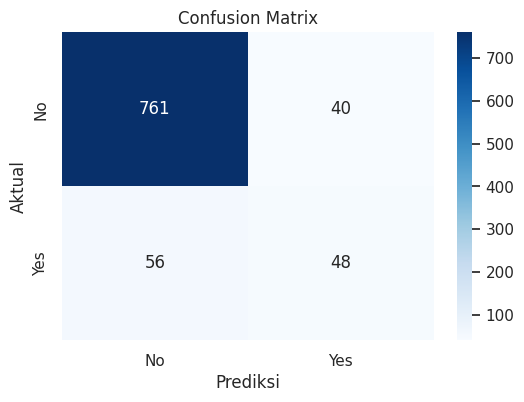

In [26]:
# A. Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

In [28]:
# B. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       801
           1       0.55      0.46      0.50       104

    accuracy                           0.89       905
   macro avg       0.74      0.71      0.72       905
weighted avg       0.89      0.89      0.89       905



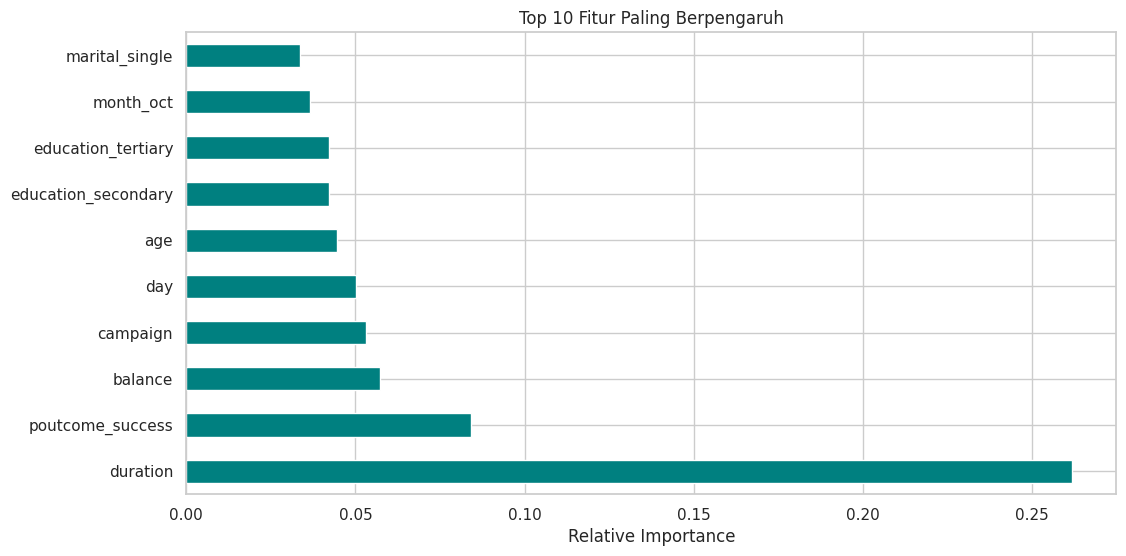

In [29]:
# C. Feature Importance (Fitur Paling Berpengaruh)
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Fitur Paling Berpengaruh')
plt.xlabel('Relative Importance')
plt.show()